# Network Intrusion Detection System

## Exploratory Data Analysis

This notebook performs the initial exploration and understanding of
the NSL-KDD dataset used for developing the network intrusion
detection and risk classification framework.

In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nChecking required libraries...\n")

libraries = [
    "numpy",
    "pandas",
    "matplotlib",
    "sklearn",
    "scipy"
]

for library in libraries:
    try:
        module = __import__(library)
        version = getattr(module, "__version__", "Version not available")
        print(f"✓ {library}: {version}")
    except ImportError:
        print(f"✗ {library}: NOT INSTALLED")

Python version:
3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]

Checking required libraries...

✓ numpy: 2.3.4
✓ pandas: 3.0.2
✓ matplotlib: 3.10.7
✓ sklearn: 1.8.0
✓ scipy: 1.17.1


In [2]:
import pandas as pd

# Path to the NSL-KDD training dataset
train_path = "../data/raw/KDDTrain+.txt"

# Load the dataset
train_df = pd.read_csv(train_path, sep="\t", header=None)
# Display the first 5 rows
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
column_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty"
]

train_df.columns = column_names

print(train_df.columns.tolist())
train_df.head()


['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty']


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
print("Dataset shape:")
print(train_df.shape)

print("\nData types:")
print(train_df.dtypes)

print("\nMissing values:")
print(train_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(train_df.duplicated().sum())

Dataset shape:
(125973, 43)

Data types:
duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate            

0

Duplicate rows:
0


In [5]:
print("Number of unique labels:", train_df["label"].nunique())

print("\nAll attack labels:")
print(train_df["label"].unique())

Number of unique labels: 23

All attack labels:
<StringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy',            'perl']
Length: 23, dtype: str


In [6]:
label_counts = train_df["label"].value_counts()

print(label_counts)

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


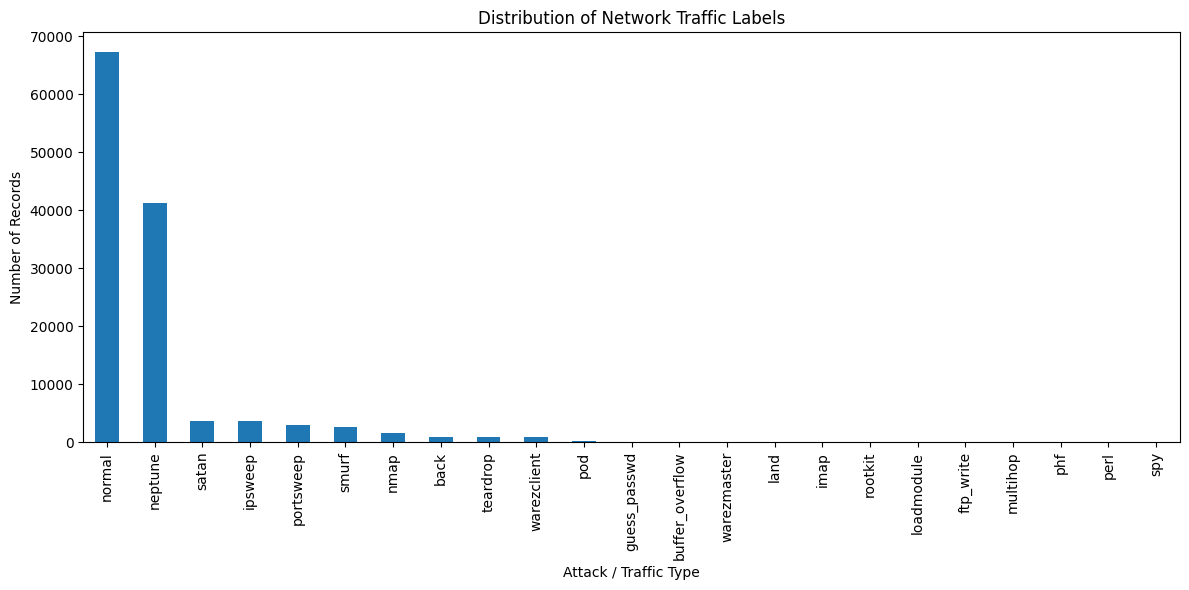

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

label_counts.plot(kind="bar")

plt.title("Distribution of Network Traffic Labels")
plt.xlabel("Attack / Traffic Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [8]:
label_percentages = (label_counts / len(train_df)) * 100

print(label_percentages.round(4))

label
normal             53.4583
neptune            32.7165
satan               2.8840
ipsweep             2.8570
portsweep           2.3267
smurf               2.1005
nmap                1.1852
back                0.7589
teardrop            0.7081
warezclient         0.7065
pod                 0.1596
guess_passwd        0.0421
buffer_overflow     0.0238
warezmaster         0.0159
land                0.0143
imap                0.0087
rootkit             0.0079
loadmodule          0.0071
ftp_write           0.0064
multihop            0.0056
phf                 0.0032
perl                0.0024
spy                 0.0016
Name: count, dtype: float64


In [9]:
attack_category_map = {
    # DoS attacks
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",

    # Probe attacks
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",

    # R2L attacks
    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",

    # U2R attacks
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R",

    # Normal traffic
    "normal": "Normal"
}

train_df["attack_category"] = train_df["label"].map(attack_category_map)

print(train_df[["label", "attack_category"]].drop_duplicates().sort_values("label"))

                 label attack_category
366               back             DoS
5579   buffer_overflow             U2R
2294         ftp_write             R2L
689       guess_passwd             R2L
6086              imap             R2L
17             ipsweep           Probe
16015             land             DoS
19448       loadmodule             U2R
3005          multihop             R2L
2              neptune             DoS
56                nmap           Probe
0               normal          Normal
66007             perl             U2R
10738              phf             R2L
211                pod             DoS
33           portsweep           Probe
3173           rootkit             U2R
62               satan           Probe
138              smurf             DoS
21445              spy             R2L
46            teardrop             DoS
13         warezclient             R2L
7040       warezmaster             R2L


In [10]:
train_df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,attack_category
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,DoS
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,Normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,Normal


In [11]:
category_counts = train_df["attack_category"].value_counts()

print(category_counts)

attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


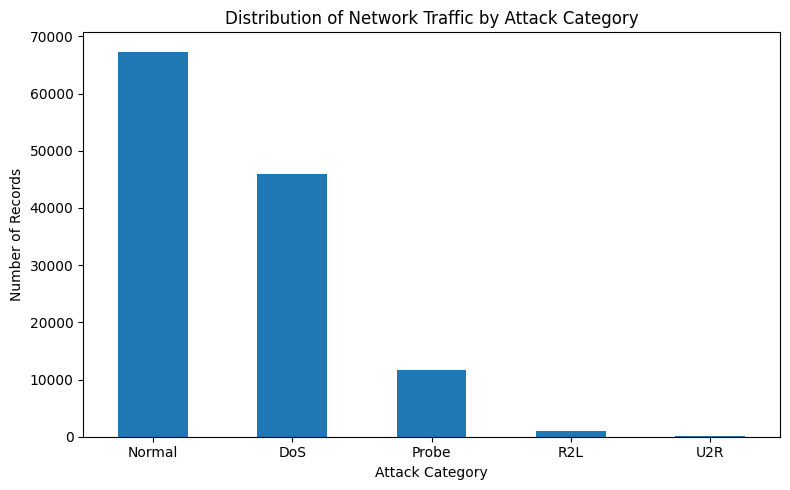

In [12]:
plt.figure(figsize=(8, 5))

category_counts.plot(kind="bar")

plt.title("Distribution of Network Traffic by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
categorical_features = ["protocol_type", "service", "flag"]

for feature in categorical_features:
    print(f"{feature}: {train_df[feature].nunique()} unique values")

protocol_type: 3 unique values
service: 70 unique values
flag: 11 unique values


In [14]:
for feature in categorical_features:
    print(f"\n{feature}:")
    print(train_df[feature].unique())


protocol_type:
<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

service:
<StringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop_3',        'nnsp',
         'IRC',       'pop_2',     'printer',       'tim_i',     

In [15]:
for feature in categorical_features:
    print(f"\n===== {feature} =====")
    print(train_df[feature].value_counts())


===== protocol_type =====
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

===== service =====
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64

===== flag =====
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64


In [16]:
numerical_features = train_df.select_dtypes(include=["int64", "float64"]).columns

print("Number of numerical columns:", len(numerical_features))
print("\nNumerical columns:")
print(numerical_features.tolist())

Number of numerical columns: 39

Numerical columns:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty']


In [17]:
numerical_features = [
    col for col in train_df.select_dtypes(include=["int64", "float64"]).columns
    if col != "difficulty"
]

print("Number of numerical network features:", len(numerical_features))
print("\nNumerical network features:")
print(numerical_features)

Number of numerical network features: 38

Numerical network features:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [18]:
train_df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [19]:
constant_features = [
    feature
    for feature in numerical_features
    if train_df[feature].nunique() == 1
]

print("Constant numerical features:")
print(constant_features)

print("\nNumber of constant features:", len(constant_features))

Constant numerical features:
['num_outbound_cmds']

Number of constant features: 1


In [20]:
skewness = train_df[numerical_features].skew().sort_values(ascending=False)

print(skewness)

is_host_login                  354.926753
dst_bytes                      290.052911
num_compromised                250.107883
num_root                       236.913724
src_bytes                      190.669347
urgent                         149.914509
land                            70.965063
num_shells                      59.592151
num_file_creations              55.665341
num_failed_logins               53.764424
num_access_files                45.554961
su_attempted                    42.435591
root_shell                      27.247411
hot                             12.589886
duration                        11.880230
wrong_fragment                  11.457988
is_guest_login                  10.155746
dst_host_srv_diff_host_rate      5.548174
srv_count                        4.694162
diff_srv_rate                    4.379815
dst_host_diff_srv_rate           3.609600
srv_diff_host_rate               2.860355
dst_host_rerror_rate             2.347446
dst_host_srv_rerror_rate         2

In [21]:
highly_skewed = skewness[abs(skewness) > 5]

print("Features with |skewness| > 5:")
print(highly_skewed)

print("\nNumber of highly skewed features:", len(highly_skewed))

Features with |skewness| > 5:
is_host_login                  354.926753
dst_bytes                      290.052911
num_compromised                250.107883
num_root                       236.913724
src_bytes                      190.669347
urgent                         149.914509
land                            70.965063
num_shells                      59.592151
num_file_creations              55.665341
num_failed_logins               53.764424
num_access_files                45.554961
su_attempted                    42.435591
root_shell                      27.247411
hot                             12.589886
duration                        11.880230
wrong_fragment                  11.457988
is_guest_login                  10.155746
dst_host_srv_diff_host_rate      5.548174
dtype: float64

Number of highly skewed features: 18


In [22]:
zero_percentage = (train_df[numerical_features] == 0).mean() * 100

zero_percentage = zero_percentage.sort_values(ascending=False)

print(zero_percentage)

num_outbound_cmds              100.000000
is_host_login                   99.999206
urgent                          99.992856
land                            99.980154
num_shells                      99.962690
su_attempted                    99.936494
num_failed_logins               99.903154
root_shell                      99.865844
num_file_creations              99.772173
num_access_files                99.705492
num_root                        99.484810
wrong_fragment                  99.134735
is_guest_login                  99.057735
num_compromised                 98.979146
hot                             97.879704
duration                        92.047502
rerror_rate                     87.148040
srv_rerror_rate                 87.135339
dst_host_srv_rerror_rate        84.634009
dst_host_rerror_rate            81.904853
srv_diff_host_rate              77.456280
srv_serror_rate                 70.454780
dst_host_srv_diff_host_rate     68.986211
serror_rate                     68

In [23]:
high_zero_features = zero_percentage[zero_percentage > 90]

print("Features with more than 90% zero values:")
print(high_zero_features)

print("\nNumber of such features:", len(high_zero_features))

Features with more than 90% zero values:
num_outbound_cmds     100.000000
is_host_login          99.999206
urgent                 99.992856
land                   99.980154
num_shells             99.962690
su_attempted           99.936494
num_failed_logins      99.903154
root_shell             99.865844
num_file_creations     99.772173
num_access_files       99.705492
num_root               99.484810
wrong_fragment         99.134735
is_guest_login         99.057735
num_compromised        98.979146
hot                    97.879704
duration               92.047502
dtype: float64

Number of such features: 16


In [24]:
category_means = train_df.groupby("attack_category")[numerical_features].mean()

category_means

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
attack_category,,,,,,,,,,,,,,,,,,,,,
DoS,0.006227,1176.321162,169.201537,0.000392,0.062229,0.000000,0.039889,0.000000,0.020837,0.019226,...,244.600475,26.524005,0.123423,0.066333,0.049492,0.001647,0.747922,0.744434,0.157569,0.151286
Normal,168.587396,13133.279331,4329.685223,0.000104,0.000000,0.000148,0.230655,0.001381,0.710646,0.507076,...,147.431923,190.285761,0.811875,0.040134,0.121726,0.025996,0.013930,0.006116,0.046589,0.044698
Probe,2074.858185,385679.838367,181074.911805,0.000000,0.000000,0.000000,0.001630,0.000343,0.007121,0.000601,...,145.204101,42.367193,0.390825,0.401263,0.651840,0.187343,0.044757,0.039799,0.389717,0.441030
R2L,633.417085,307727.300503,81822.026131,0.000000,0.000000,0.003015,8.334673,0.056281,0.913568,0.077387,...,89.037186,42.440201,0.727377,0.021307,0.596915,0.085739,0.023849,0.015960,0.051116,0.047367
U2R,80.942308,906.230769,5141.961538,0.000000,0.000000,0.019231,1.403846,0.019231,0.884615,1.211538,...,47.769231,9.884615,0.781154,0.040000,0.568269,0.081154,0.000000,0.004808,0.039615,0.019038


In [25]:
selected_features = [
    "src_bytes",
    "dst_bytes",
    "duration",
    "logged_in",
    "count",
    "same_srv_rate"
]

category_means[selected_features]

,src_bytes,dst_bytes,duration,logged_in,count,same_srv_rate
attack_category,,,,,,
DoS,1176.321162,169.201537,0.006227,0.020837,178.090034,0.191887
Normal,13133.279331,4329.685223,168.587396,0.710646,22.517945,0.969360
Probe,385679.838367,181074.911805,2074.858185,0.007121,77.052248,0.697196
R2L,307727.300503,81822.026131,633.417085,0.913568,1.297487,0.996653
U2R,906.230769,5141.961538,80.942308,0.884615,5.807692,0.931538


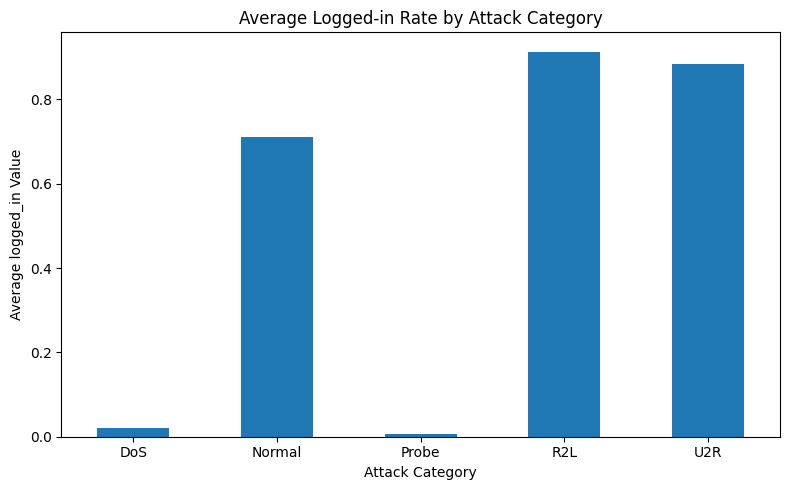

In [26]:
plt.figure(figsize=(8, 5))

category_means["logged_in"].plot(kind="bar")

plt.title("Average Logged-in Rate by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average logged_in Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

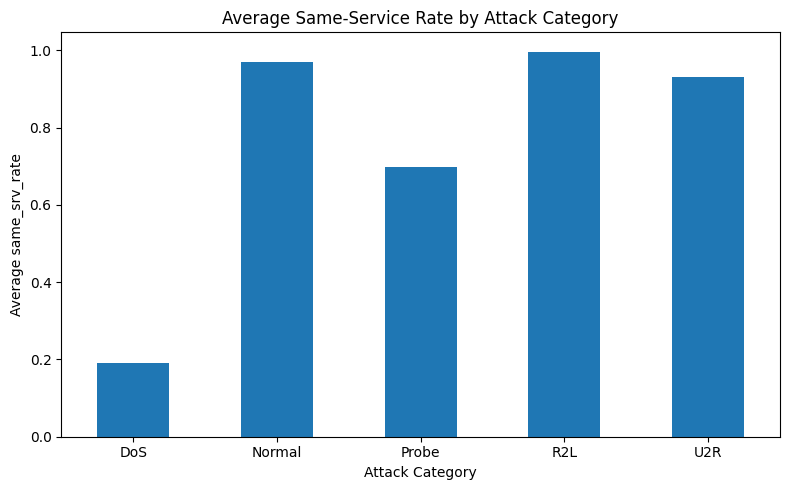

In [27]:
plt.figure(figsize=(8, 5))

category_means["same_srv_rate"].plot(kind="bar")

plt.title("Average Same-Service Rate by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average same_srv_rate")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

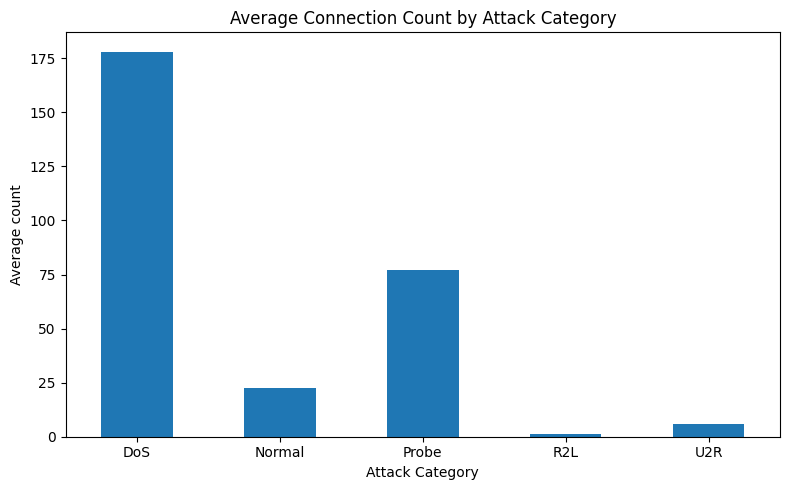

In [28]:
plt.figure(figsize=(8, 5))

category_means["count"].plot(kind="bar")

plt.title("Average Connection Count by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

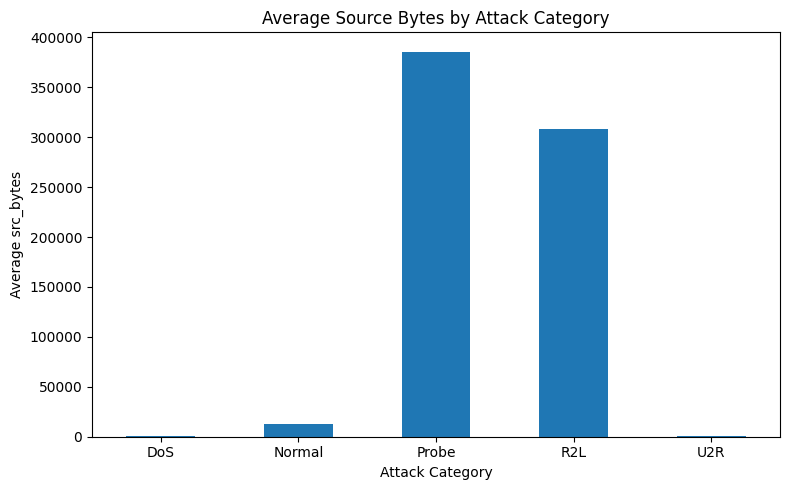

In [29]:
plt.figure(figsize=(8, 5))

category_means["src_bytes"].plot(kind="bar")

plt.title("Average Source Bytes by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average src_bytes")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

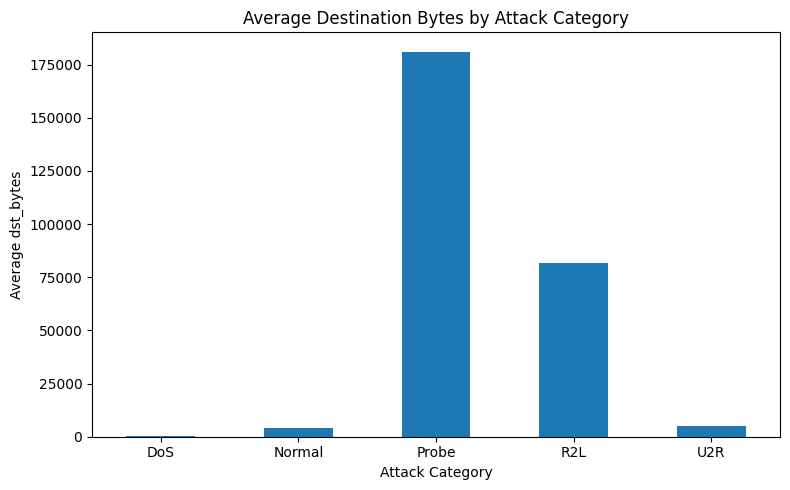

In [30]:
plt.figure(figsize=(8, 5))

category_means["dst_bytes"].plot(kind="bar")

plt.title("Average Destination Bytes by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average dst_bytes")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

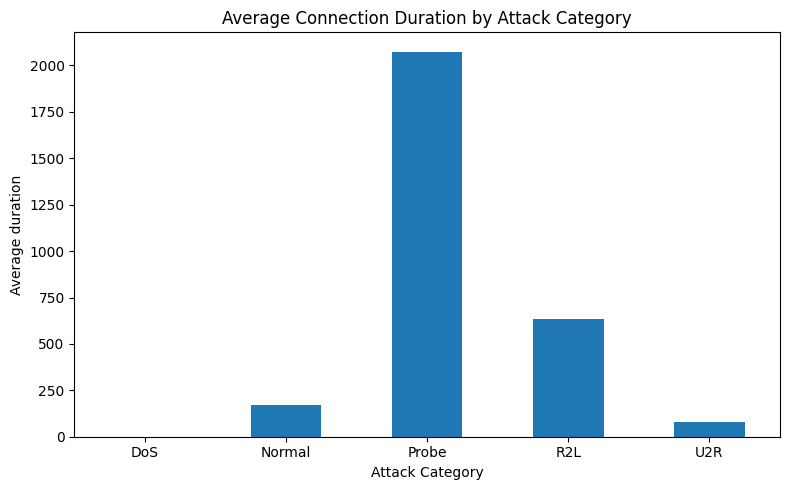

In [31]:
plt.figure(figsize=(8, 5))

category_means["duration"].plot(kind="bar")

plt.title("Average Connection Duration by Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Average duration")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

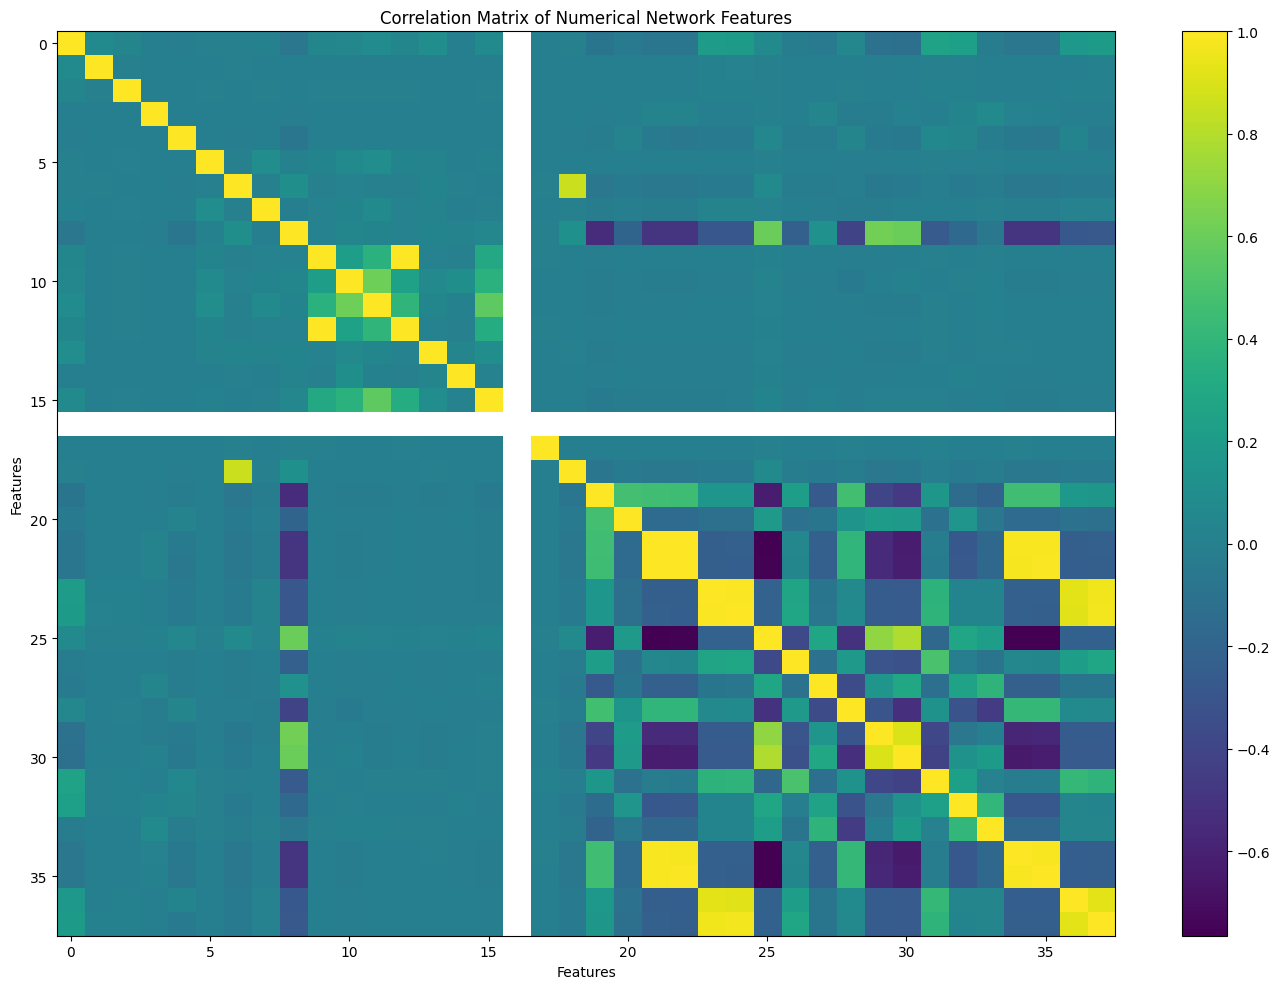

In [32]:
correlation_matrix = train_df[numerical_features].corr()

plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.title("Correlation Matrix of Numerical Network Features")
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [33]:
corr_pairs = correlation_matrix.where(
    ~correlation_matrix.eq(1)
).stack().sort_values(ascending=False)

print("Strongest positive correlations:")
print(corr_pairs.head(10))

print("\nStrongest negative correlations:")
print(corr_pairs.tail(10))

Strongest positive correlations:
num_root                  num_compromised             0.998833
num_compromised           num_root                    0.998833
srv_serror_rate           serror_rate                 0.993289
serror_rate               srv_serror_rate             0.993289
rerror_rate               srv_rerror_rate             0.989008
srv_rerror_rate           rerror_rate                 0.989008
dst_host_srv_serror_rate  srv_serror_rate             0.986252
srv_serror_rate           dst_host_srv_serror_rate    0.986252
dst_host_serror_rate      dst_host_srv_serror_rate    0.985052
dst_host_srv_serror_rate  dst_host_serror_rate        0.985052
dtype: float64

Strongest negative correlations:
dst_host_srv_diff_host_rate  num_outbound_cmds             NaN
                             dst_host_srv_diff_host_rate   NaN
dst_host_serror_rate         num_outbound_cmds             NaN
                             dst_host_serror_rate          NaN
dst_host_srv_serror_rate     num_out

In [34]:
import numpy as np

# Get correlation pairs
corr = train_df[numerical_features].corr()

# Keep only the upper triangle to avoid duplicate pairs
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# Convert to pairs and sort by absolute correlation
corr_pairs = (
    upper.stack()
    .sort_values(key=abs, ascending=False)
)

# Display the 15 strongest relationships
top_corr = corr_pairs.head(15)

print("Top 15 strongest feature correlations:")
print(top_corr)

Top 15 strongest feature correlations:
num_compromised       num_root                    0.998833
serror_rate           srv_serror_rate             0.993289
rerror_rate           srv_rerror_rate             0.989008
srv_serror_rate       dst_host_srv_serror_rate    0.986252
dst_host_serror_rate  dst_host_srv_serror_rate    0.985052
serror_rate           dst_host_srv_serror_rate    0.981139
                      dst_host_serror_rate        0.979373
srv_serror_rate       dst_host_serror_rate        0.977596
srv_rerror_rate       dst_host_srv_rerror_rate    0.970208
rerror_rate           dst_host_srv_rerror_rate    0.964449
                      dst_host_rerror_rate        0.926749
dst_host_rerror_rate  dst_host_srv_rerror_rate    0.924688
srv_rerror_rate       dst_host_rerror_rate        0.917822
dst_host_srv_count    dst_host_same_srv_rate      0.896663
hot                   is_guest_login              0.860288
dtype: float64


In [35]:
protocol_category = pd.crosstab(
    train_df["attack_category"],
    train_df["protocol_type"],
    normalize="index"
) * 100

print("Protocol type distribution within each attack category (%):")
print(protocol_category.round(2))

Protocol type distribution within each attack category (%):
protocol_type     icmp     tcp    udp
attack_category                      
DoS               6.20   91.86   1.94
Normal            1.94   79.59  18.46
Probe            35.48   50.25  14.28
R2L               0.00  100.00   0.00
U2R               0.00   94.23   5.77


In [36]:
for category in train_df["attack_category"].unique():
    print(f"\n===== {category} =====")
    
    service_counts = (
        train_df[train_df["attack_category"] == category]["service"]
        .value_counts()
        .head(10)
    )
    
    print(service_counts)


===== Normal =====
service
http        38049
domain_u     9034
smtp         7029
ftp_data     4984
other        2604
private       982
ftp           918
telnet        917
urp_i         599
finger        545
Name: count, dtype: int64

===== DoS =====
service
private     15971
ecr_i        2844
http         2255
telnet       1312
ftp_data     1209
finger       1168
Z39_50        851
uucp          769
courier       726
auth          703
Name: count, dtype: int64

===== R2L =====
service
ftp_data    604
ftp         312
telnet       57
imap4        11
other         5
http          4
login         2
Name: count, dtype: int64

===== Probe =====
service
private     4900
eco_i       4089
other       1689
finger        54
ftp_data      51
smtp          43
ecr_i         43
gopher        33
telnet        33
ftp           32
Name: count, dtype: int64

===== U2R =====
service
telnet      34
ftp_data    12
ftp          3
other        3
Name: count, dtype: int64


In [37]:
flag_category = pd.crosstab(
    train_df["attack_category"],
    train_df["flag"],
    normalize="index"
) * 100

print("Flag distribution within each attack category (%):")
print(flag_category.round(2))

Flag distribution within each attack category (%):
flag              OTH    REJ  RSTO  RSTOS0   RSTR     S0    S1    S2    S3  \
attack_category                                                              
DoS              0.00  12.35  2.65    0.00   0.20  74.78  0.00  0.01  0.00   
Normal           0.02   4.00  0.33    0.00   0.22   0.53  0.54  0.18  0.07   
Probe            0.30  24.61  0.69    0.88  18.70   1.31  0.01  0.02  0.01   
R2L              0.00   0.00  4.62    0.00   0.50   0.00  0.10  0.10  0.30   
U2R              0.00   0.00  1.92    0.00   0.00   0.00  0.00  0.00  0.00   

flag                SF    SH  
attack_category               
DoS              10.01  0.00  
Normal           94.13  0.00  
Probe            51.19  2.27  
R2L              93.97  0.40  
U2R              98.08  0.00  


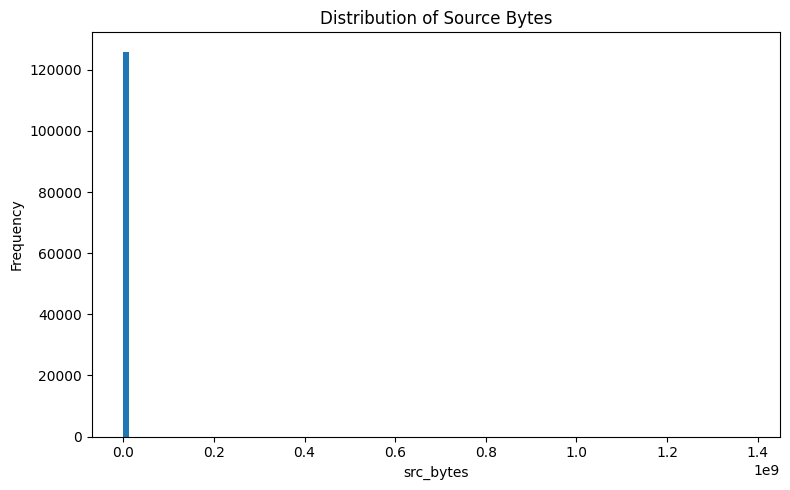

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(train_df["src_bytes"], bins=100)

plt.title("Distribution of Source Bytes")
plt.xlabel("src_bytes")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

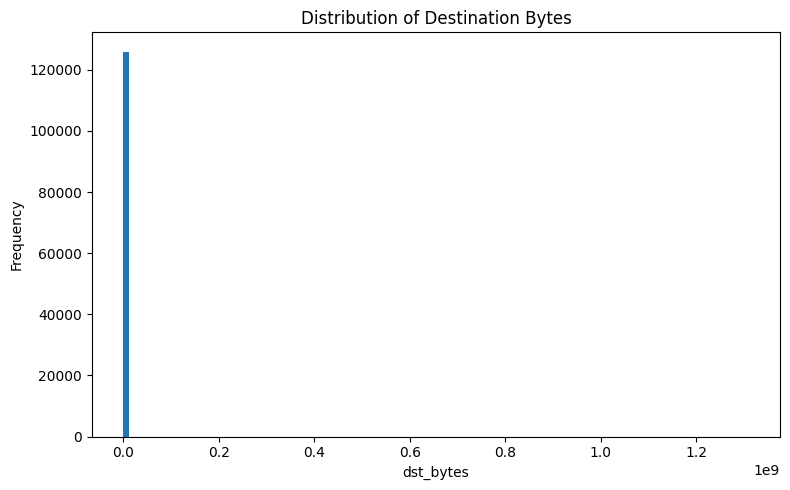

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(train_df["dst_bytes"], bins=100)

plt.title("Distribution of Destination Bytes")
plt.xlabel("dst_bytes")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

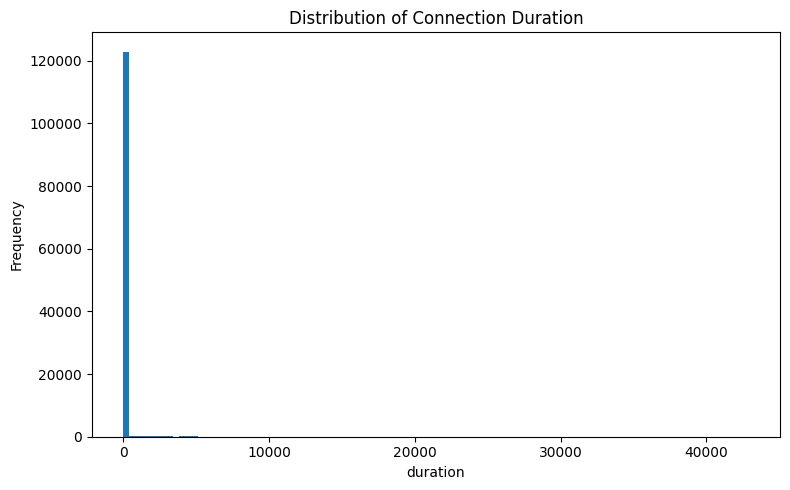

In [40]:
plt.figure(figsize=(8, 5))

plt.hist(train_df["duration"], bins=100)

plt.title("Distribution of Connection Duration")
plt.xlabel("duration")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [41]:
test_path = "../data/raw/KDDTest+.txt"

test_df = pd.read_csv(test_path, sep="\t", header=None)

print("Test dataset shape:")
print(test_df.shape)

print("\nLast 5 columns:")
print(test_df.iloc[:, -5:].head())

print("\nNumber of columns:")
print(test_df.shape[1])

Test dataset shape:
(22544, 42)

Last 5 columns:
    37   38    39    40      41
0  0.0  0.0  1.00  1.00  Attack
1  0.0  0.0  1.00  1.00  Attack
2  0.0  0.0  0.00  0.00  Normal
3  0.0  0.0  0.00  0.00  Attack
4  0.0  0.0  0.83  0.71  Attack

Number of columns:
42


In [42]:
test_column_names = column_names[:-1]

test_df.columns = test_column_names

print("Test dataset shape:")
print(test_df.shape)

print("\nTest dataset columns:")
print(test_df.columns.tolist())

print("\nMissing values:")
print(test_df.isnull().sum().sum())

print("\nNumber of unique labels:")
print(test_df["label"].nunique())

Test dataset shape:
(22544, 42)

Test dataset columns:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

Missing values:
0

Number of unique labels:
2


In [43]:
print("Test dataset labels:")
print(test_df["label"].value_counts())

print("\nUnique test labels:")
print(test_df["label"].unique())

Test dataset labels:
label
Attack    12833
Normal     9711
Name: count, dtype: int64

Unique test labels:
<StringArray>
['Attack', 'Normal']
Length: 2, dtype: str


In [44]:
print("Dataset comparison")
print("-------------------")

print(f"Training samples : {len(train_df)}")
print(f"Testing samples  : {len(test_df)}")

print(f"\nTraining features: {len(train_df.columns) - 2}")
print(f"Testing features : {len(test_df.columns) - 1}")

Dataset comparison
-------------------
Training samples : 125973
Testing samples  : 22544

Training features: 42
Testing features : 41


# Step 2 — Data Preprocessing & Feature Engineering

## Task 1 — Separate Features, Metadata and Labels

In [45]:
# Separate the input features and target label

X = train_df.drop(columns=["label", "difficulty", "attack_category"])
y = train_df["label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (125973, 41)
Target shape: (125973,)

Feature columns:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## Task 2 — Create Target Representations

In [46]:
# Create binary target
# 0 = Normal
# 1 = Attack

y_binary = (y != "normal").astype(int)

print("Binary target distribution:")
print(y_binary.value_counts())

Binary target distribution:
label
0    67343
1    58630
Name: count, dtype: int64


In [47]:
# Create multiclass target

y_multiclass = y.map(attack_category_map)

print("Multiclass target distribution:")
print(y_multiclass.value_counts())

Multiclass target distribution:
label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [48]:
print("\nMissing values in multiclass target:", y_multiclass.isna().sum())


Missing values in multiclass target: 0


## Task 3 — Identify Numerical and Categorical Features

In [49]:
# Identify categorical and numerical features

categorical_features = X.select_dtypes(include=["str"]).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

print("\nTotal features:", len(categorical_features) + len(numerical_features))

Categorical features:
['protocol_type', 'service', 'flag']

Number of categorical features: 3

Numerical features:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

Number of numerical features: 38

Total features: 41


## Task 4 — Remove Non-Informative Features

In [50]:
# Check constant features

constant_features = [
    feature for feature in numerical_features
    if X[feature].nunique() == 1
]

print("Constant features:")
print(constant_features)

print("\nNumber of constant features:", len(constant_features))

Constant features:
['num_outbound_cmds']

Number of constant features: 1


In [51]:
# Remove constant features

X = X.drop(columns=constant_features)

# Update the numerical feature list
numerical_features = [
    feature for feature in numerical_features
    if feature not in constant_features
]

print("Removed features:", constant_features)
print("New feature matrix shape:", X.shape)
print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Removed features: ['num_outbound_cmds']
New feature matrix shape: (125973, 40)
Number of numerical features: 37
Number of categorical features: 3


## Task 5 — Handle Highly Skewed Numerical Features

In [52]:
# Calculate skewness of the numerical features

skewness = X[numerical_features].skew()

# Show features with strong right/left skew
highly_skewed = skewness[abs(skewness) > 5].sort_values(
    key=abs,
    ascending=False
)

print("Highly skewed features (|skewness| > 5):")
print(highly_skewed)

print("\nNumber of highly skewed features:", len(highly_skewed))

Highly skewed features (|skewness| > 5):
is_host_login                  354.926753
dst_bytes                      290.052911
num_compromised                250.107883
num_root                       236.913724
src_bytes                      190.669347
urgent                         149.914509
land                            70.965063
num_shells                      59.592151
num_file_creations              55.665341
num_failed_logins               53.764424
num_access_files                45.554961
su_attempted                    42.435591
root_shell                      27.247411
hot                             12.589886
duration                        11.880230
wrong_fragment                  11.457988
is_guest_login                  10.155746
dst_host_srv_diff_host_rate      5.548174
dtype: float64

Number of highly skewed features: 18


In [53]:
# Check basic statistics of highly skewed features

skewed_stats = X[highly_skewed.index].describe().T[
    ["min", "25%", "50%", "75%", "max"]
]

print(skewed_stats)

                             min  25%   50%     75%           max
is_host_login                0.0  0.0   0.0    0.00  1.000000e+00
dst_bytes                    0.0  0.0   0.0  516.00  1.309937e+09
num_compromised              0.0  0.0   0.0    0.00  7.479000e+03
num_root                     0.0  0.0   0.0    0.00  7.468000e+03
src_bytes                    0.0  0.0  44.0  276.00  1.379964e+09
urgent                       0.0  0.0   0.0    0.00  3.000000e+00
land                         0.0  0.0   0.0    0.00  1.000000e+00
num_shells                   0.0  0.0   0.0    0.00  2.000000e+00
num_file_creations           0.0  0.0   0.0    0.00  4.300000e+01
num_failed_logins            0.0  0.0   0.0    0.00  5.000000e+00
num_access_files             0.0  0.0   0.0    0.00  9.000000e+00
su_attempted                 0.0  0.0   0.0    0.00  2.000000e+00
root_shell                   0.0  0.0   0.0    0.00  1.000000e+00
hot                          0.0  0.0   0.0    0.00  7.700000e+01
duration  

In [54]:
import numpy as np

# Apply log1p transformation to heavily right-skewed features
log_features = ["src_bytes", "dst_bytes", "duration"]

for feature in log_features:
    X[feature] = np.log1p(X[feature])

print("Log-transformed features:")
print(log_features)

print("\nSkewness after transformation:")
print(X[log_features].skew())

Log-transformed features:
['src_bytes', 'dst_bytes', 'duration']

Skewness after transformation:
src_bytes    0.310643
dst_bytes    0.493738
duration     5.338451
dtype: float64


## Task 6 — Numerical Feature Scaling

In [55]:
# Inspect numerical feature ranges before scaling

numerical_ranges = X[numerical_features].agg(["min", "max"]).T

print(numerical_ranges)

                             min          max
duration                     0.0    10.666837
src_bytes                    0.0    21.045323
dst_bytes                    0.0    20.993245
land                         0.0     1.000000
wrong_fragment               0.0     3.000000
urgent                       0.0     3.000000
hot                          0.0    77.000000
num_failed_logins            0.0     5.000000
logged_in                    0.0     1.000000
num_compromised              0.0  7479.000000
root_shell                   0.0     1.000000
su_attempted                 0.0     2.000000
num_root                     0.0  7468.000000
num_file_creations           0.0    43.000000
num_shells                   0.0     2.000000
num_access_files             0.0     9.000000
is_host_login                0.0     1.000000
is_guest_login               0.0     1.000000
count                        0.0   511.000000
srv_count                    0.0   511.000000
serror_rate                  0.0  

## Task 7 — Encode Categorical Features

In [56]:
# Inspect the categorical feature categories

for feature in categorical_features:
    print(f"\n{feature}")
    print("Number of unique categories:", X[feature].nunique())
    print("Categories:")
    print(X[feature].unique())


protocol_type
Number of unique categories: 3
Categories:
<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

service
Number of unique categories: 70
Categories:
<StringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop

In [57]:
from sklearn.preprocessing import OneHotEncoder

# Create the one-hot encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit and transform the categorical features
X_categorical_encoded = encoder.fit_transform(
    X[categorical_features]
)

print("Encoded categorical data shape:", X_categorical_encoded.shape)

print("\nNumber of encoded categories:",
      len(encoder.get_feature_names_out()))

print("\nFirst 10 encoded feature names:")
print(encoder.get_feature_names_out()[:10])

Encoded categorical data shape: (125973, 84)

Number of encoded categories: 84

First 10 encoded feature names:
['protocol_type_icmp' 'protocol_type_tcp' 'protocol_type_udp'
 'service_IRC' 'service_X11' 'service_Z39_50' 'service_aol' 'service_auth'
 'service_bgp' 'service_courier']


## Task 8 — Train / Validation Split

In [58]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_binary_train, y_binary_val, y_multiclass_train, y_multiclass_val = train_test_split(
    X,
    y_binary,
    y_multiclass,
    test_size=0.20,
    random_state=42,
    stratify=y_multiclass
)

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)

print("\nTraining binary target shape:", y_binary_train.shape)
print("Validation binary target shape:", y_binary_val.shape)

print("\nTraining multiclass target distribution:")
print(y_multiclass_train.value_counts())

print("\nValidation multiclass target distribution:")
print(y_multiclass_val.value_counts())

Training feature shape: (100778, 40)
Validation feature shape: (25195, 40)

Training binary target shape: (100778,)
Validation binary target shape: (25195,)

Training multiclass target distribution:
label
Normal    53874
DoS       36741
Probe      9325
R2L         796
U2R          42
Name: count, dtype: int64

Validation multiclass target distribution:
label
Normal    13469
DoS        9186
Probe      2331
R2L         199
U2R          10
Name: count, dtype: int64


## Task 9 — Handle Class Imbalance

In [59]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the five classes
classes = np.unique(y_multiclass_train)

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_multiclass_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
for class_name, weight in class_weights.items():
    print(f"{class_name}: {weight:.4f}")

Class weights:
DoS: 0.5486
Normal: 0.3741
Probe: 2.1615
R2L: 25.3211
U2R: 479.8952


## Task 10 — Build the Classification Preprocessing Pipeline

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import numpy as np

# Features that need log transformation
log_features = ["src_bytes", "dst_bytes", "duration"]

# Remaining numerical features
scaled_numerical_features = [
    feature for feature in numerical_features
    if feature not in log_features
]

# Pipeline for log-transformed numerical features
log_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# Pipeline for remaining numerical features
numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Pipeline for categorical features
categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

print("Log-transformed numerical features:", log_features)
print("Other numerical features:", len(scaled_numerical_features))
print("Categorical features:", categorical_features)

Log-transformed numerical features: ['src_bytes', 'dst_bytes', 'duration']
Other numerical features: 34
Categorical features: ['protocol_type', 'service', 'flag']


In [61]:
# Create the complete preprocessing transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("log_numeric", log_pipeline, log_features),
        ("numeric", numerical_pipeline, scaled_numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing transformer created successfully.")

Preprocessing transformer created successfully.


In [62]:
# Restore the original values of the log-transformed features

for feature in log_features:
    X[feature] = train_df[feature]

# Recreate the train/validation split using the restored X

X_train, X_val, y_binary_train, y_binary_val, y_multiclass_train, y_multiclass_val = train_test_split(
    X,
    y_binary,
    y_multiclass,
    test_size=0.20,
    random_state=42,
    stratify=y_multiclass
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\nOriginal src_bytes example:")
print(X_train["src_bytes"].head())

X_train shape: (100778, 40)
X_val shape: (25195, 40)

Original src_bytes example:
120533     0
79337     45
70499      0
18855      0
81240      0
Name: src_bytes, dtype: int64


In [63]:
# Fit the preprocessor only on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation data using the already fitted preprocessor
X_val_processed = preprocessor.transform(X_val)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)

Processed training shape: (100778, 121)
Processed validation shape: (25195, 121)


## Task 11 — Prepare Data for K-Means

In [64]:
# Use the processed training features for K-Means
# Labels are NOT included.

X_kmeans = X_train_processed.copy()

print("K-Means input shape:", X_kmeans.shape)
print("K-Means input type:", type(X_kmeans))

print("\nBinary target used in K-Means:", "No")
print("Multiclass target used in K-Means:", "No")

K-Means input shape: (100778, 121)
K-Means input type: <class 'numpy.ndarray'>

Binary target used in K-Means: No
Multiclass target used in K-Means: No


## Task 12 — Principal Component Analysis (PCA)

In [65]:
from sklearn.decomposition import PCA

# Fit PCA with all possible components
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_kmeans)

print("Original number of features:", X_kmeans.shape[1])
print("Number of PCA components:", X_pca_full.shape[1])

Original number of features: 121
Number of PCA components: 121


In [66]:
# Calculate cumulative explained variance

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()

for i, variance in enumerate(cumulative_variance, start=1):
    if variance >= 0.90:
        print("Components needed for 90% variance:", i)
        print("Cumulative explained variance:", variance)
        break

Components needed for 90% variance: 19
Cumulative explained variance: 0.912422280533008


In [67]:
# Find the number of components needed for 95% variance

for i, variance in enumerate(cumulative_variance, start=1):
    if variance >= 0.95:
        print("Components needed for 95% variance:", i)
        print("Cumulative explained variance:", variance)
        break

Components needed for 95% variance: 23
Cumulative explained variance: 0.954448497550467


In [68]:
# Create PCA representation with 23 components

pca = PCA(n_components=23)

X_pca = pca.fit_transform(X_kmeans)

print("Original feature count:", X_kmeans.shape[1])
print("PCA feature count:", X_pca.shape[1])

print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original feature count: 121
PCA feature count: 23
Explained variance: 0.9544484975504671


## Task 13 — Prepare Sequential Data for HMM

In [69]:
# Define sequence length for HMM

sequence_length = 10

n_samples = X_pca.shape[0]

n_sequences = n_samples // sequence_length

print("Number of samples:", n_samples)
print("Sequence length:", sequence_length)
print("Complete sequences:", n_sequences)
print("Unused samples:", n_samples % sequence_length)

Number of samples: 100778
Sequence length: 10
Complete sequences: 10077
Unused samples: 8


In [70]:
# Construct fixed-length sequences for HMM

X_hmm = X_pca[:n_sequences * sequence_length]

X_hmm = X_hmm.reshape(
    n_sequences,
    sequence_length,
    X_pca.shape[1]
)

print("HMM input shape:", X_hmm.shape)

HMM input shape: (10077, 10, 23)


In [71]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Flatten the HMM sequences so each observation is one row
X_hmm_observations = X_hmm.reshape(-1, X_hmm.shape[-1])

print("Observation matrix shape:", X_hmm_observations.shape)

Observation matrix shape: (100770, 23)


In [72]:
# Compare different numbers of clusters

sample_size = 10000

# Use a fixed sample for reproducibility
X_sample = X_hmm_observations[:sample_size]

k_values = [5, 10, 15, 20]

silhouette_scores = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_sample)
    
    score = silhouette_score(
        X_sample,
        cluster_labels
    )
    
    silhouette_scores[k] = score
    
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 5, Silhouette Score = 0.4753
K = 10, Silhouette Score = 0.5104
K = 15, Silhouette Score = 0.5309
K = 20, Silhouette Score = 0.5514


In [73]:
# Fit the final K-Means model using all HMM observations

kmeans_hmm = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=10
)

hmm_cluster_labels = kmeans_hmm.fit_predict(X_hmm_observations)

print("Number of observations:", len(hmm_cluster_labels))
print("Number of clusters:", len(np.unique(hmm_cluster_labels)))

print("\nCluster distribution:")
print(np.bincount(hmm_cluster_labels))

Number of observations: 100770
Number of clusters: 20

Cluster distribution:
[ 7525  9009 27797 31176 10798    94    15  3650   933   709    40     4
    19  2135    22    86  4384     1    41  2332]


In [74]:
# Convert cluster IDs into fixed-length HMM observation sequences

hmm_observation_sequences = hmm_cluster_labels.reshape(
    n_sequences,
    sequence_length
)

print("HMM observation sequence shape:",
      hmm_observation_sequences.shape)

print("\nFirst 5 HMM observation sequences:")
print(hmm_observation_sequences[:5])

HMM observation sequence shape: (10077, 10)

First 5 HMM observation sequences:
[[ 2 16  2  2  1  2  1  3 13  2]
 [16  2  3  3  2  9  2  1  3  1]
 [ 0  4  3  3  2  2  3  3  0  1]
 [ 2 13  3  4  4  3  3  2  2  2]
 [ 3  2  4  0  2  3  2  2  0  3]]


In [80]:
print("========== FINAL PREPROCESSING CHECK ==========")

print("\n1. Classification data")
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\n2. Processed classification data")
print("X_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)

print("\n3. Binary target")
print("y_binary_train shape:", y_binary_train.shape)
print("y_binary_val shape:", y_binary_val.shape)

print("\n4. Multiclass target")
print("y_multiclass_train shape:", y_multiclass_train.shape)
print("y_multiclass_val shape:", y_multiclass_val.shape)

print("\n5. PCA data")
print("X_pca shape:", X_pca.shape)
print("PCA components:", X_pca.shape[1])

print("\n6. HMM data")
print("HMM observations:", X_hmm_observations.shape)
print("HMM sequences:", hmm_observation_sequences.shape)

print("\n7. Missing values")
print("Training processed data contains NaN:",
      np.isnan(X_train_processed).any())
print("Validation processed data contains NaN:",
      np.isnan(X_val_processed).any())

print("\n8. Multiclass classes")
print(np.unique(y_multiclass_train))

print("\n========== CHECK COMPLETE ==========")

========== FINAL PREPROCESSING CHECK ==========

1. Classification data
X_train shape: (100778, 40)
X_val shape: (25195, 40)

2. Processed classification data
X_train_processed shape: (100778, 121)
X_val_processed shape: (25195, 121)

3. Binary target
y_binary_train shape: (100778,)
y_binary_val shape: (25195,)

4. Multiclass target
y_multiclass_train shape: (100778,)
y_multiclass_val shape: (25195,)

5. PCA data
X_pca shape: (100778, 23)
PCA components: 23

6. HMM data
HMM observations: (100770, 23)
HMM sequences: (10077, 10)

7. Missing values
Training processed data contains NaN: False
Validation processed data contains NaN: False

8. Multiclass classes
['DoS' 'Normal' 'Probe' 'R2L' 'U2R']

========== CHECK COMPLETE ==========


In [76]:
import os

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/X_train_processed.npy", X_train_processed)
np.save("../data/processed/X_val_processed.npy", X_val_processed)

np.save("../data/processed/y_binary_train.npy", y_binary_train)
np.save("../data/processed/y_binary_val.npy", y_binary_val)

np.save("../data/processed/y_multiclass_train.npy", y_multiclass_train)
np.save("../data/processed/y_multiclass_val.npy", y_multiclass_val)

print("Processed data saved successfully.")

Processed data saved successfully.


In [77]:
feature_names = preprocessor.get_feature_names_out()

np.save(
    "../data/processed/feature_names.npy",
    feature_names
)

print("Feature names saved.")

Feature names saved.


In [78]:
import joblib

joblib.dump(
    preprocessor,
    "../data/processed/preprocessor.joblib"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [79]:
np.save("../data/processed/X_pca.npy", X_pca)
print("PCA representation saved.")

PCA representation saved.
